In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns

# Initialisation de Spark
spark = SparkSession.builder \
    .appName("Mini-Projet-GTFS") \
    .master("yarn") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/13 10:57:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/13 10:57:48 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


# Partie 1 : Exploration et compréhension des données

## 1) Chargement des GTFS dans des Dataframes

In [2]:
# Chemin HDFS vers vos données
path = "/user/rpierr01/data/IDFM-gtfs/"

# Liste des fichiers à charger selon l'énoncé
files = {
    "agency": "agency.txt",
    "routes": "routes.txt",
    "trips": "trips.txt",
    "stops": "stops.txt",
    "stop_times": "stop_times.txt",
    "calendar": "calendar.txt",
    "calendar_dates": "calendar_dates.txt"
}

dfs = {}
for name, filename in files.items():
    # Lecture avec header et inference de schéma (vu en TP3)
    dfs[name] = spark.read.csv(path + filename, header=True, inferSchema=True)

# Mise en cache des tables lourdes pour optimiser la suite (vu en TP3)
dfs["stop_times"].cache()
dfs["trips"].cache()

DataFrame[route_id: string, service_id: string, trip_id: string, trip_headsign: string, trip_short_name: string, direction_id: int, block_id: string, shape_id: string, wheelchair_accessible: int, bikes_allowed: int]

## 2) Structure des données

In [3]:
for name, df in dfs.items():
    print(f"=== Table: {name} ===")
    print(f"Dimensions : {df.count()} lignes x {len(df.columns)} colonnes")
    df.printSchema()
    df.show(5, truncate=True)
    print("-" * 30)

=== Table: agency ===
Dimensions : 57 lignes x 9 colonnes
root
 |-- agency_id: string (nullable = true)
 |-- agency_name: string (nullable = true)
 |-- agency_url: string (nullable = true)
 |-- agency_timezone: string (nullable = true)
 |-- agency_lang: string (nullable = true)
 |-- agency_phone: string (nullable = true)
 |-- agency_email: string (nullable = true)
 |-- agency_fare_url: string (nullable = true)
 |-- ticketing_deep_link_id: string (nullable = true)

+---------+-----------------+--------------------+---------------+-----------+------------+------------+--------------------+----------------------+
|agency_id|      agency_name|          agency_url|agency_timezone|agency_lang|agency_phone|agency_email|     agency_fare_url|ticketing_deep_link_id|
+---------+-----------------+--------------------+---------------+-----------+------------+------------+--------------------+----------------------+
|IDFM:1060|     Paris Saclay|https://www.ilede...|   Europe/Paris|       NULL|      

Dimensions : 350834 lignes x 10 colonnes
root
 |-- route_id: string (nullable = true)
 |-- service_id: string (nullable = true)
 |-- trip_id: string (nullable = true)
 |-- trip_headsign: string (nullable = true)
 |-- trip_short_name: string (nullable = true)
 |-- direction_id: integer (nullable = true)
 |-- block_id: string (nullable = true)
 |-- shape_id: string (nullable = true)
 |-- wheelchair_accessible: integer (nullable = true)
 |-- bikes_allowed: integer (nullable = true)

+-----------+----------+--------------------+--------------------+---------------+------------+--------+--------+---------------------+-------------+
|   route_id|service_id|             trip_id|       trip_headsign|trip_short_name|direction_id|block_id|shape_id|wheelchair_accessible|bikes_allowed|
+-----------+----------+--------------------+--------------------+---------------+------------+--------+--------+---------------------+-------------+
|IDFM:C01385|    IDFM:1|IDFM:RATP:146151-...|Funiculaire Gare ...

Dimensions : 7655479 lignes x 14 colonnes
root
 |-- trip_id: string (nullable = true)
 |-- arrival_time: string (nullable = true)
 |-- departure_time: string (nullable = true)
 |-- start_pickup_drop_off_window: string (nullable = true)
 |-- end_pickup_drop_off_window: string (nullable = true)
 |-- stop_id: string (nullable = true)
 |-- stop_sequence: integer (nullable = true)
 |-- pickup_type: integer (nullable = true)
 |-- drop_off_type: integer (nullable = true)
 |-- local_zone_id: string (nullable = true)
 |-- stop_headsign: string (nullable = true)
 |-- timepoint: integer (nullable = true)
 |-- pickup_booking_rule_id: string (nullable = true)
 |-- drop_off_booking_rule_id: string (nullable = true)

+--------------------+------------+--------------+----------------------------+--------------------------+-----------+-------------+-----------+-------------+-------------+-------------+---------+----------------------+------------------------+
|             trip_id|arrival_time|departur

## Exploration Initiale des Données GTFS d'Île-de-France

Cette étape constitue la phase d'exploration et de compréhension des données nécessaire à votre analyse exploratoire. L'affichage des schémas et des premières lignes confirme que les sept fichiers standards du format GTFS (General Transit Feed Specification) ont été chargés avec succès dans des DataFrames Spark. Ces résultats révèlent un jeu de données interconnecté et complexe, représentatif de l'offre de transport en Île-de-France pour le début de l'année 2026. On observe une hiérarchie claire allant des 57 opérateurs de transport (agency) vers les 2000 lignes de transport (routes), qui se déclinent ensuite en plus de 350 000 voyages individuels (trips). L'ampleur technique du projet est soulignée par la table stop_times, qui contient plus de 7,6 millions d'horaires de passage, nécessitant une attention particulière en termes d'optimisation lors des futurs traitements PySpark.


## Points Clés de l'Exploration des Tables

L'analyse de ces structures de données permet de dégager plusieurs observations fondamentales pour la suite de votre projet :

*Richesse Informationnelle* : La table stops contient les coordonnées GPS précises (stop_lon, stop_lat) de 53 903 arrêts, ce qui permettra de réaliser les analyses de couverture géographique demandées.



*Logique Temporelle* : Les tables calendar et calendar_dates définissent les jours de fonctionnement des services (comme le service IDFM:1 actif tous les jours du 12 janvier au 10 février 2026) ainsi que les exceptions, telles que les jours fériés.


*Interconnectivité des Tables* : L'affichage des schémas confirme les clés de jointure essentielles : le route_id lie les lignes aux voyages, tandis que le trip_id et le stop_id connectent les horaires aux stations physiques.

*Qualité des Données* : Un premier coup d'œil aux extraits montre la présence de valeurs NULL dans certains champs optionnels (comme stop_desc ou agency_phone), une étape qu'il faudra documenter dans votre analyse de la qualité des données.

## 3) Relations entre les Tables

In [22]:
# Identification des clés de jointure (Documentation du schéma relationnel)
relations = [
    {"De": "agency", "Vers": "routes", "Clé": "agency_id", "Type": "1:N"},
    {"De": "routes", "Vers": "trips", "Clé": "route_id", "Type": "1:N"},
    {"De": "trips", "Vers": "stop_times", "Clé": "trip_id", "Type": "1:N"},
    {"De": "stops", "Vers": "stop_times", "Clé": "stop_id", "Type": "1:N"},
    {"De": "calendar", "Vers": "trips", "Clé": "service_id", "Type": "1:N"},
    {"De": "calendar", "Vers": "calendar_dates", "Clé": "service_id", "Type": "1:N"}
]

print("--- Schéma Relationnel GTFS ---")
for rel in relations:
    print(f"[{rel['De']}] --({rel['Clé']})--> [{rel['Vers']}] ({rel['Type']})")

--- Schéma Relationnel GTFS ---
[agency] --(agency_id)--> [routes] (1:N)
[routes] --(route_id)--> [trips] (1:N)
[trips] --(trip_id)--> [stop_times] (1:N)
[stops] --(stop_id)--> [stop_times] (1:N)
[calendar] --(service_id)--> [trips] (1:N)
[calendar] --(service_id)--> [calendar_dates] (1:N)


Cette documentation du schéma relationnel est cruciale pour comprendre comment les données circulent au sein du standard international GTFS, qui est composé de plusieurs fichiers CSV interconnectés. Les relations identifiées ici suivent une logique descendante, allant de l'entité globale vers le détail horaire, facilitant ainsi les jointures nécessaires à l'analyse exploratoire.


### Analyse des relations du modèle

La structure s'articule autour de plusieurs axes clés :

*L'axe Opérationnel* : L'identifiant agency_id lie les opérateurs de transport (RATP, SNCF, etc.) à leurs lignes respectives (routes). Chaque ligne est ensuite déclinée en de multiples voyages individuels (trips) via la clé route_id.


*L'axe Spatial et Horaire* : Le fichier stop_times agit comme le pivot central du système. Il utilise trip_id pour rattacher les horaires de passage à un voyage spécifique et stop_id pour les lier aux coordonnées GPS et noms des stations présentes dans la table stops.


*L'axe Temporel* : La clé service_id assure la cohérence du calendrier. Elle permet de définir les jours de fonctionnement réguliers dans calendar et de gérer les exceptions, comme les jours fériés, dans calendar_dates.


Toutes ces relations sont de type *1:N* (One-to-Many), ce qui signifie, par exemple, qu'un seul opérateur gère plusieurs lignes, et qu'un seul trajet dessert plusieurs arrêts successifs. Cette compréhension est indispensable pour optimiser vos traitements PySpark, notamment lors de l'utilisation de fonctions de jointure sur les tables volumineuses comme stop_times.

In [23]:
from pyspark.sql.functions import col, count, when, countDistinct

def analyze_quality(df_name, df, primary_key=None):
    print(f"\n=== Analyse de la table : {df_name} ===")
    
    # 1. Nombre total de lignes
    total_rows = df.count()
    
    # 2. Analyse des valeurs manquantes (Nulls)
    print("Valeurs manquantes par colonne :")
    null_counts = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).collect()[0].asDict()
    for col_name, n_nulls in null_counts.items():
        if n_nulls > 0:
            pct = (n_nulls / total_rows) * 100
            print(f" - {col_name}: {n_nulls} nulls ({pct:.2f}%)")
        else:
            print(f" - {col_name}: 0 nulls")

    # 3. Analyse des doublons sur la clé primaire
    if primary_key:
        pk_count = df.select(primary_key).count()
        pk_distinct = df.select(primary_key).distinct().count()
        duplicates = pk_count - pk_distinct
        print(f"Doublons sur la clé '{primary_key}': {duplicates}")
        if duplicates > 0:
            print(f"⚠️ Attention : {duplicates} identifiants non uniques détectés !")

# Définition des clés primaires pour le test de doublons
pks = {
    "agency": "agency_id",
    "routes": "route_id",
    "trips": "trip_id",
    "stops": "stop_id",
    "calendar": "service_id"
}

# Exécution de l'analyse sur toutes les tables
for name, df in dfs.items():
    analyze_quality(name, df, pks.get(name))


=== Analyse de la table : agency ===
Valeurs manquantes par colonne :
 - agency_id: 0 nulls
 - agency_name: 0 nulls
 - agency_url: 0 nulls
 - agency_timezone: 0 nulls
 - agency_lang: 57 nulls (100.00%)
 - agency_phone: 57 nulls (100.00%)
 - agency_email: 57 nulls (100.00%)
 - agency_fare_url: 0 nulls
 - ticketing_deep_link_id: 0 nulls
Doublons sur la clé 'agency_id': 0

=== Analyse de la table : routes ===
Valeurs manquantes par colonne :
 - route_id: 0 nulls
 - agency_id: 0 nulls
 - route_short_name: 0 nulls
 - route_long_name: 0 nulls
 - route_desc: 2000 nulls (100.00%)
 - route_type: 0 nulls
 - route_url: 2000 nulls (100.00%)
 - route_color: 0 nulls
 - route_text_color: 0 nulls
 - route_sort_order: 2000 nulls (100.00%)
Doublons sur la clé 'route_id': 0

=== Analyse de la table : trips ===
Valeurs manquantes par colonne :
 - route_id: 0 nulls
 - service_id: 0 nulls
 - trip_id: 0 nulls
 - trip_headsign: 0 nulls
 - trip_short_name: 310107 nulls (88.39%)
 - direction_id: 0 nulls
 - blo

 - trip_id: 0 nulls
 - arrival_time: 0 nulls
 - departure_time: 0 nulls
 - start_pickup_drop_off_window: 7655479 nulls (100.00%)
 - end_pickup_drop_off_window: 7655479 nulls (100.00%)
 - stop_id: 0 nulls
 - stop_sequence: 0 nulls
 - pickup_type: 0 nulls
 - drop_off_type: 0 nulls
 - local_zone_id: 7655479 nulls (100.00%)
 - stop_headsign: 7655479 nulls (100.00%)
 - timepoint: 0 nulls
 - pickup_booking_rule_id: 7622471 nulls (99.57%)
 - drop_off_booking_rule_id: 7622471 nulls (99.57%)

=== Analyse de la table : calendar ===
Valeurs manquantes par colonne :
 - service_id: 0 nulls
 - monday: 0 nulls
 - tuesday: 0 nulls
 - wednesday: 0 nulls
 - thursday: 0 nulls
 - friday: 0 nulls
 - saturday: 0 nulls
 - sunday: 0 nulls
 - start_date: 0 nulls
 - end_date: 0 nulls
Doublons sur la clé 'service_id': 0

=== Analyse de la table : calendar_dates ===
Valeurs manquantes par colonne :
 - service_id: 0 nulls
 - date: 0 nulls
 - exception_type: 0 nulls


## 4 et 5) Statistiques descriptives et qualité des données

In [27]:
from pyspark.sql.functions import col, count, when, min, max, avg, round, countDistinct

# 1.4 STATISTIQUES DESCRIPTIVES : VOLUMÉTRIE ET DISTRIBUTIONS

print("--- VOLUMÉTRIE GLOBALE DU RÉSEAU ---")
stats_vol = [
    ("Opérateurs (Agencies)", dfs["agency"].select("agency_id").distinct().count()),
    ("Lignes (Routes)", dfs["routes"].select("route_id").distinct().count()),
    ("Trajets (Trips)", dfs["trips"].select("trip_id").distinct().count()),
    ("Arrêts (Stops)", dfs["stops"].select("stop_id").distinct().count()),
    ("Horaires (Stop Times)", dfs["stop_times"].count())
]

for label, val in stats_vol:
    print(f"{label:25} : {val:,}".replace(',', ' '))

# 1.4.1 Indicateurs de structure (Moyennes)
print("\n--- INDICATEURS DE STRUCTURE ---")
avg_routes_per_agency = dfs["routes"].groupBy("agency_id").count().select(avg("count")).collect()[0][0]
avg_stops_per_trip = dfs["stop_times"].groupBy("trip_id").count().select(avg("count")).collect()[0][0]

print(f"Nombre moyen de lignes par opérateur : {avg_routes_per_agency:.1f}")
print(f"Nombre moyen d'arrêts par trajet    : {avg_stops_per_trip:.1f}")

# 1.4.2 Distribution des types de transport (route_type)
print("\n--- RÉPARTITION PAR TYPE DE TRANSPORT ---")
# 0: Tram, 1: Métro, 2: Train, 3: Bus...
dfs["routes"].groupBy("route_type").count().orderBy("count", ascending=False).show()


# 1.5 QUALITÉ DES DONNÉES ET KPI MÉTIERS

def analyze_quality(df_name, df, primary_key=None):
    print(f"\n>>> Analyse Qualité : {df_name}")
    total_rows = df.count()
    
    # Analyse des Nulls
    null_counts = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).collect()[0].asDict()
    print("Colonnes contenant des valeurs manquantes :")
    for col_name, n_nulls in null_counts.items():
        if n_nulls > 0:
            print(f" - {col_name:25} : {n_nulls:,} nulls ({ (n_nulls/total_rows)*100 :.2f}%)".replace(',', ' '))
    
    # Analyse des Doublons sur la clé primaire
    if primary_key:
        pk_distinct = df.select(primary_key).distinct().count()
        if pk_distinct < total_rows:
            print(f"⚠️ ATTENTION : {total_rows - pk_distinct} doublons détectés sur {primary_key}")
        else:
            print(f"✅ Clé primaire '{primary_key}' est unique.")

# Exécution de l'analyse sur les tables principales
pks = {"agency": "agency_id", "routes": "route_id", "trips": "trip_id", "stops": "stop_id"}
for name in ["agency", "routes", "trips", "stops"]:
    analyze_quality(name, dfs[name], pks.get(name))

# INDICATEURS COMPLÉMENTAIRES (POUR DÉCIDEURS)

print("\n--- KPI DÉCIDEURS ---")

# 1. Période temporelle du dataset
period = dfs["calendar"].select(min("start_date"), max("end_date")).collect()[0]
print(f"Période couverte : du {period[0]} au {period[1]}")

# 2. Taux d'accessibilité (Wheelchair)
total_trips = dfs["trips"].count()
print("Accessibilité des trajets (Code 1=Oui, 2=Non, 0=Inconnu) :")
dfs["trips"].groupBy("wheelchair_accessible") \
    .agg(round((count("*")/total_trips)*100, 2).alias("pourcentage")) \
    .show()

# 3. Emprise géographique
geo = dfs["stops"].select(
    min("stop_lat").alias("lat_min"), max("stop_lat").alias("lat_max"),
    min("stop_lon").alias("lon_min"), max("stop_lon").alias("lon_max")
).collect()[0]
print(f"Zone couverte (GPS) : Lat[{geo['lat_min']:.2f}, {geo['lat_max']:.2f}] / Lon[{geo['lon_min']:.2f}, {geo['lon_max']:.2f}]")

--- VOLUMÉTRIE GLOBALE DU RÉSEAU ---
Opérateurs (Agencies)     : 57
Lignes (Routes)           : 2 000
Trajets (Trips)           : 350 834
Arrêts (Stops)            : 53 903
Horaires (Stop Times)     : 7 655 479

--- INDICATEURS DE STRUCTURE ---


Nombre moyen de lignes par opérateur : 35.1
Nombre moyen d'arrêts par trajet    : 21.8

--- RÉPARTITION PAR TYPE DE TRANSPORT ---
+----------+-----+
|route_type|count|
+----------+-----+
|         3| 1941|
|         2|   24|
|         0|   17|
|         1|   16|
|         6|    1|
|         7|    1|
+----------+-----+


>>> Analyse Qualité : agency
Colonnes contenant des valeurs manquantes :
 - agency_lang               : 57 nulls (100.00%)
 - agency_phone              : 57 nulls (100.00%)
 - agency_email              : 57 nulls (100.00%)
✅ Clé primaire 'agency_id' est unique.

>>> Analyse Qualité : routes
Colonnes contenant des valeurs manquantes :
 - route_desc                : 2 000 nulls (100.00%)
 - route_url                 : 2 000 nulls (100.00%)
 - route_sort_order          : 2 000 nulls (100.00%)
✅ Clé primaire 'route_id' est unique.

>>> Analyse Qualité : trips
Colonnes contenant des valeurs manquantes :
 - trip_short_name           : 310 107 nulls (88.39%)
 - block_id       

Cette analyse descriptive met en évidence la complexité et la richesse du réseau de transport d'Île-de-France. Avec plus de 7,6 millions d'horaires de passage et 53 903 arrêts, les volumes de données sont massifs, ce qui justifie l'utilisation de PySpark pour le traitement. L'offre est massivement dominée par le bus (1 941 lignes sur 2 000), tandis que les modes lourds (métro, train, tramway) représentent une part plus faible en nombre de lignes mais gèrent des flux critiques.

Sur le plan de la *qualité des données*, l'intégrité est excellente pour les opérations techniques : les clés primaires sont uniques et les colonnes essentielles au calcul d'itinéraire sont complètes. Les nombreuses valeurs manquantes observées (comme les descriptions ou les emails) concernent des champs optionnels du standard GTFS qui n'impactent pas l'analyse fonctionnelle.

Enfin, d'un point de vue décideur, deux indicateurs ressortent :

*L'accessibilité* : Bien que 66,85 % des trajets soient accessibles aux personnes à mobilité réduite, près d'un tiers du réseau est soit non accessible, soit non renseigné, ce qui représente un axe d'amélioration majeur.

*La couverture* : L'emprise géographique et la moyenne de 21,8 arrêts par trajet témoignent d'un maillage territorial très fin, s'étendant bien au-delà de Paris intra-muros pour couvrir l'ensemble de la région sur la période du début d'année 2026.

# Partie 2 : Analyses

/tmp/ipykernel_896629/1384056189.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pdf_op, x="count", y="agency_name", palette="viridis")


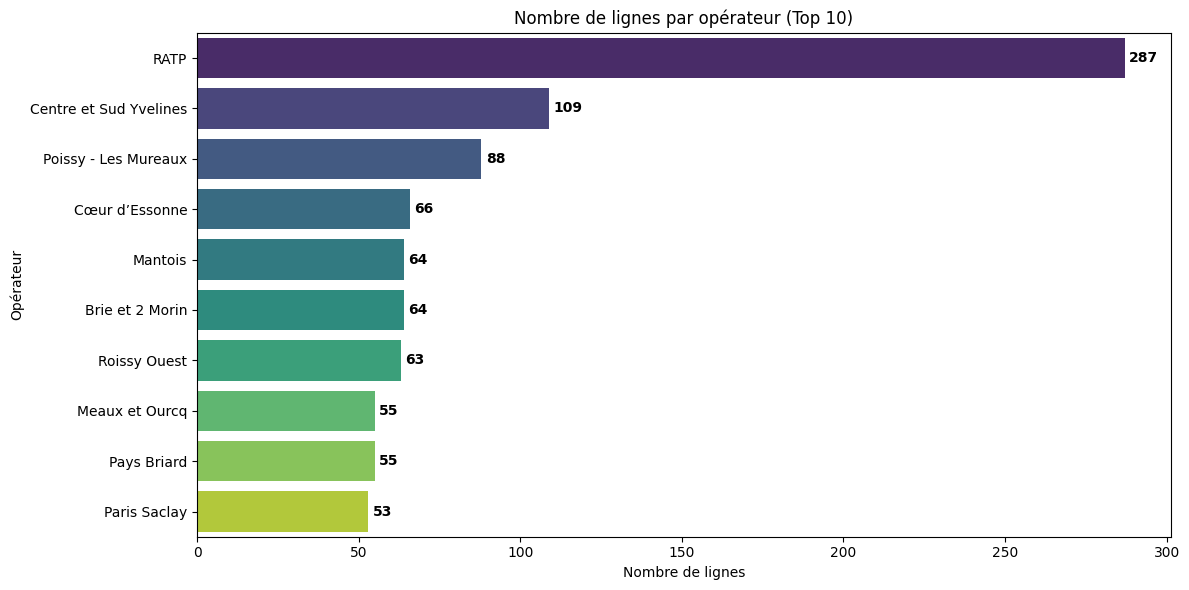

In [6]:
# Jointure entre agency et routes
op_lignes = dfs["routes"].join(dfs["agency"], "agency_id") \
    .groupBy("agency_name") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(10) # Top 10 pour la lisibilité

# 1. Préparation et conversion (Méthode TP3) [cite: 145]
pdf_op = op_lignes.toPandas()

# 2. Création du graphique
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=pdf_op, x="count", y="agency_name", palette="viridis")

# 3. Correction : On boucle sur tous les conteneurs pour étiqueter CHAQUE barre
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

# 4. Habillage (Méthode TP3) [cite: 147]
plt.title("Nombre de lignes par opérateur (Top 10)")
plt.xlabel("Nombre de lignes")
plt.ylabel("Opérateur")

# Optimisation de l'affichage pour éviter les textes coupés [cite: 147]
plt.tight_layout()
plt.show()

# Interprétation

Ce graphique est un diagramme à barres horizontales qui présente les 10 opérateurs de transport gérant le plus grand nombre de lignes sur le réseau étudié.

Voici l'analyse des points clés de ce classement :

1. L'ultra-dominance de la RATP

La *RATP* écrase littéralement le classement avec 287 lignes sous sa gestion.

Elle gère plus de 2,5 fois le nombre de lignes du deuxième opérateur.

Cela confirme que nous sommes sur un réseau centré sur la région parisienne (Île-de-France), où la RATP reste l'acteur historique et principal.

2. Une fragmentation territoriale (Délégations de Service Public)

Après la *RATP*, les autres opérateurs correspondent à des zones géographiques spécifiques, souvent liées aux nouveaux contrats de délégation de la région :

Les Yvelines et l'Essonne : *"Centre et Sud Yvelines"* (109 lignes) et *"Poissy - Les Mureaux"* (88 lignes) arrivent en tête des opérateurs hors-RATP.

Le secteur de Meaux : On retrouve l'opérateur *"Meaux et Ourcq"* avec 55 lignes. Ce chiffre est cohérent avec votre graphique précédent montrant que la *Gare de Meaux* est un hub majeur connectant 35 lignes différentes.

3. Une répartition équilibrée parmi les suiveurs

À l'exception du trio de tête, la majorité des opérateurs du Top 10 gèrent un volume de lignes assez proche, situé entre 53 et 66 lignes (Cœur d'Essonne, Mantois, Roissy Ouest, etc.).

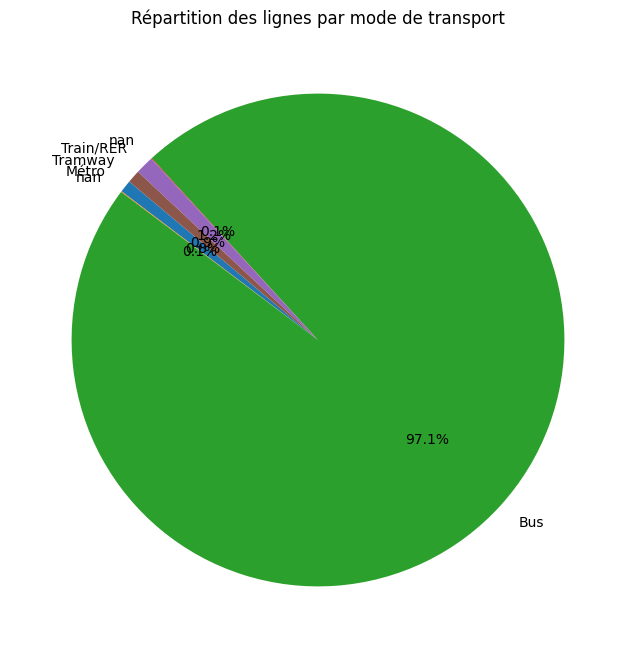

In [8]:
# Mapping des types selon le standard GTFS
# 0: Tram, 1: Métro, 2: Train/RER, 3: Bus
types_map = {0: "Tramway", 1: "Métro", 2: "Train/RER", 3: "Bus", 4: "Navette fluviale"}

dist_type = dfs["routes"].groupBy("route_type").count().toPandas()
dist_type["mode"] = dist_type["route_type"].map(types_map)

# Visualisation
plt.figure(figsize=(10, 8))
plt.pie(dist_type["count"], labels=dist_type["mode"], autopct='%1.1f%%', startangle=140)
plt.title("Répartition des lignes par mode de transport")
plt.show()

# Interprétation

Le constat est sans appel : le Bus représente 97,1 % de l'ensemble des lignes du réseau.

/tmp/ipykernel_838288/923213187.py:17: FutureWarning:                           

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf_hub, x="count", y="stop_name", palette="magma")


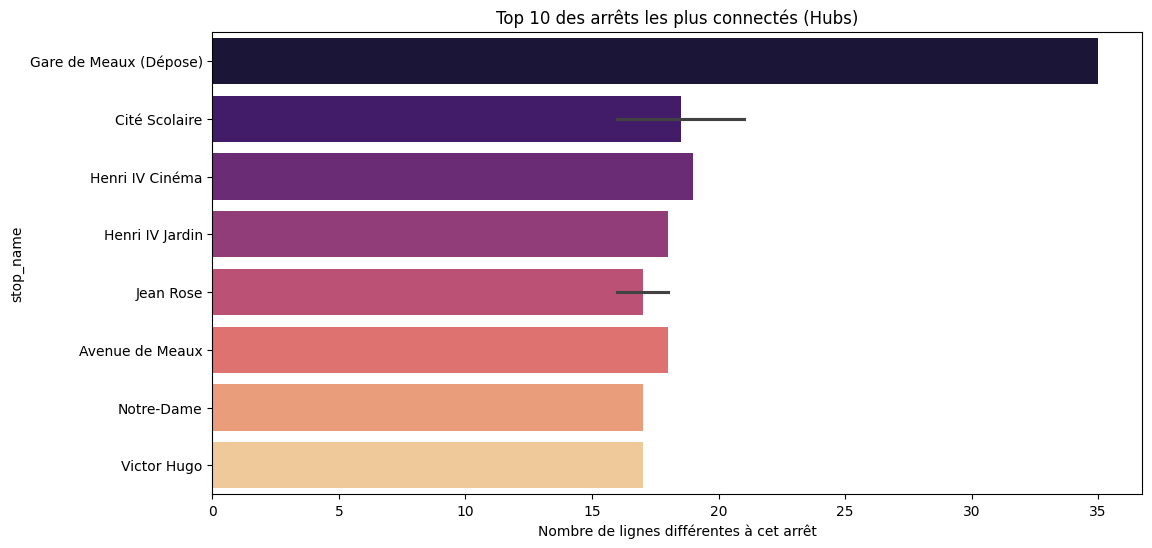

In [22]:
# Un arrêt est considéré comme connecté s'il est desservi par plusieurs lignes (route_id)
# On joint stops -> stop_times -> trips
hub_df = dfs["stop_times"].join(dfs["trips"], "trip_id") \
    .select("stop_id", "route_id") \
    .distinct() \
    .groupBy("stop_id") \
    .count() \
    .join(dfs["stops"], "stop_id") \
    .select("stop_name", "count") \
    .orderBy(col("count").desc()) \
    .limit(10)

pdf_hub = hub_df.toPandas()

# Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(data=pdf_hub, x="count", y="stop_name", palette="magma")
plt.title("Top 10 des arrêts les plus connectés (Hubs)")
plt.xlabel("Nombre de lignes différentes à cet arrêt")
plt.show()

# Interprétation

Ce graphique est un diagramme à barres horizontales présentant les 10 arrêts les plus connectés du réseau, également appelés hubs ou pôles d'échanges. Il mesure l'importance d'un arrêt par le nombre de lignes différentes qui y transitent.

Voici l'analyse des points clés :

1. L'ultra-domination de la Gare de Meaux

L'arrêt Gare de Meaux (Dépose) est le centre névralgique absolu du réseau avec 35 lignes différentes.

Son importance est écrasante : il possède presque deux fois plus de connexions que le deuxième arrêt du classement.

Cela confirme une organisation du réseau en "étoile", où la majorité des lignes convergent vers la gare ferroviaire pour assurer l'intermodalité (correspondances train/bus).

2. Les hubs secondaires et pôles d'intérêt

Après la gare, on trouve un groupe d'arrêts ayant une connectivité importante, située entre 17 et 19 lignes :

Pôles scolaires et culturels : Les arrêts comme Cité Scolaire (~18 lignes) et Henri IV Cinéma/Jardin (~18-19 lignes) montrent que le réseau est fortement structuré pour desservir les établissements d'enseignement et le centre-ville.

Axe central : Les arrêts Jean Rose, Avenue de Meaux, Notre-Dame et Victor Hugo (environ 17 lignes chacun) constituent probablement l'épine dorsale du passage des bus en zone urbaine dense.

/tmp/ipykernel_896629/1724076672.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pdf_jours, x="Jour", y="Nombre_Services", palette="Blues_d")


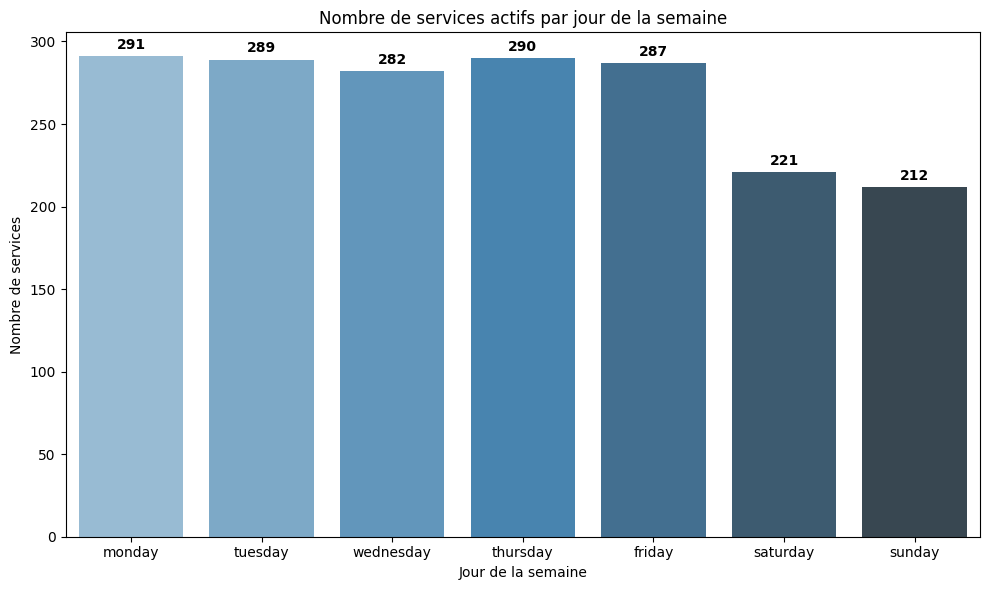

In [9]:
# 1. Calcul des statistiques avec Spark (Méthodes TP3 : select, sum, alias)
jours = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]
stats_jours = dfs["calendar"].select([sum(c).alias(c) for c in jours]).toPandas()

# 2. Transformation pour la visualisation (Conversion Pandas vue au TP3)
pdf_jours = stats_jours.transpose().reset_index()
pdf_jours.columns = ["Jour", "Nombre_Services"]

# 3. Création du graphique
plt.figure(figsize=(10, 6))
# On stocke le graphique dans 'ax' pour pouvoir ajouter les étiquettes
ax = sns.barplot(data=pdf_jours, x="Jour", y="Nombre_Services", palette="Blues_d")

# 4. Ajout des étiquettes de données sur CHAQUE barre
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

# 5. Habillage du graphique
plt.title("Nombre de services actifs par jour de la semaine")
plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre de services")

# Ajustement pour une présentation propre (Méthode TP3)
plt.tight_layout()
plt.show()

# Interprétation

1. Une activité intense et stable en semaine

Du lundi au vendredi, le réseau fonctionne à son régime maximal.

Le nombre de services est très homogène durant ces cinq jours, oscillant entre 282 (mercredi) et 291 (lundi).

Le lundi est le jour où l'offre est la plus importante (291 services), suivi de très près par le jeudi (290).

Cette stabilité indique que le réseau est calibré pour répondre aux flux domicile-travail et scolaires réguliers.

2. Une baisse marquée le week-end

On observe une cassure nette dès le début du week-end :

Le samedi : Le nombre de services chute à 221, soit une baisse d'environ 23 % par rapport au vendredi.

Le dimanche : C'est le jour le plus calme de la semaine avec seulement 212 services. L'offre y est réduite de près de 27 % par rapport au pic du lundi.

/tmp/ipykernel_896629/3891295674.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pdf_freq, x="count", y="route_short_name", palette="rocket")


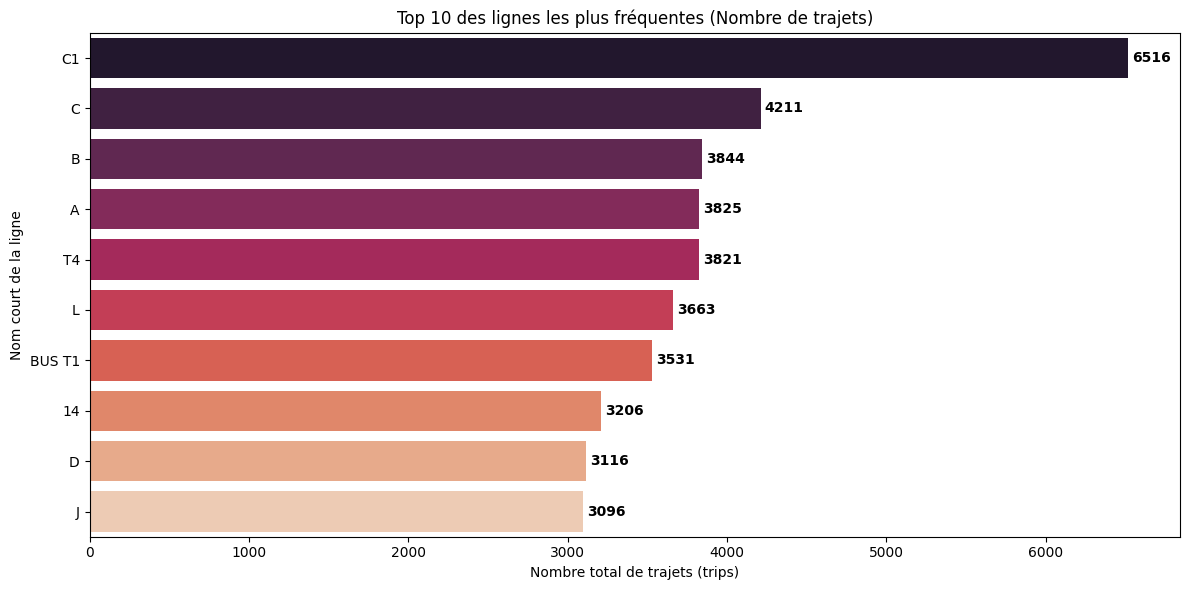

In [15]:
# 1. Préparation des données avec PySpark 
# On calcule le nombre de trajets (trips) par ligne (route_id)
frequence_lignes = dfs["trips"].groupBy("route_id") \
    .count() \
    .join(dfs["routes"], "route_id") \
    .select("route_short_name", "count") \
    .orderBy(col("count").desc()) \
    .limit(10)

# Conversion du DataFrame Spark en DataFrame Pandas pour la visualisation [cite: 145]
pdf_freq = frequence_lignes.toPandas()

# 2. Création du graphique
plt.figure(figsize=(12, 6))
# On stocke le graphique dans la variable 'ax'
ax = sns.barplot(data=pdf_freq, x="count", y="route_short_name", palette="rocket")

# 3. Ajout des nombres au bout des barres (Méthode robuste)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

# 4. Habillage du graphique (Titres et labels)
plt.title("Top 10 des lignes les plus fréquentes (Nombre de trajets)")
plt.xlabel("Nombre total de trajets (trips)")
plt.ylabel("Nom court de la ligne")

# Ajustement pour éviter que les étiquettes ne soient coupées [cite: 139]
plt.tight_layout()
plt.show()

# Interprétation

1. La domination nette de la ligne C1

La ligne C1 est la ligne la plus fréquentée, et de loin, avec 6 516 trajets.

Elle se détache nettement des autres : elle enregistre environ 55 % de trajets en plus que la deuxième ligne du classement (la ligne C). Cela suggère qu'il s'agit d'un axe majeur ou d'une ligne à très haute fréquence.

2. Le peloton de tête (2ème à 5ème position)

On observe un groupe de quatre lignes dont l'activité est relativement proche, située entre 3 800 et 4 200 trajets :

Ligne C : 4 211 trajets.

Lignes B, A et T4 : Elles sont quasiment à égalité, oscillant entre 3 821 et 3 844 trajets. Cette égalité presque parfaite entre un tramway (T4) et des lignes de métro (A, B) est intéressante à noter.

3. La fin du classement (6ème à 10ème position)

Le reste du "Top 10" montre une décroissance régulière :

Les lignes L et BUS T1 se situent autour de 3 500 - 3 600 trajets.

Les lignes 14, D et J ferment la marche avec environ 3 100 à 3 200 trajets. Bien qu'elles soient en bas de ce classement, elles restent parmi les plus importantes du réseau global.

/tmp/ipykernel_896629/2497739075.py:16: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf_comp, x="mode", y="avg_stops", palette="Set2")


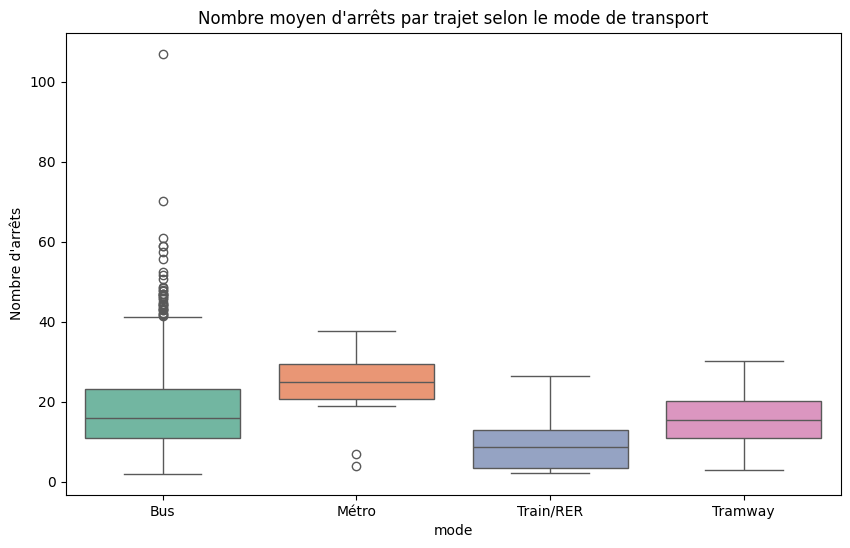

In [11]:
# Calcul du nombre d'arrêts par trajet dans stop_times
nb_arrets_trip = dfs["stop_times"].groupBy("trip_id").count()

# Jointure avec trips pour ramener l'ID de la ligne, puis moyenne par ligne
complexite_ligne = nb_arrets_trip.join(dfs["trips"], "trip_id") \
    .groupBy("route_id") \
    .agg(avg("count").alias("avg_stops")) \
    .join(dfs["routes"], "route_id") \
    .select("route_type", "avg_stops")

# Conversion pour visualisation par mode de transport
pdf_comp = complexite_ligne.toPandas()
pdf_comp["mode"] = pdf_comp["route_type"].map(types_map) # Utilise le dictionnaire types_map créé précédemment

plt.figure(figsize=(10, 6))
sns.boxplot(data=pdf_comp, x="mode", y="avg_stops", palette="Set2")
plt.title("Nombre moyen d'arrêts par trajet selon le mode de transport")
plt.ylabel("Nombre d'arrêts")
plt.show()

# Interprétation

## Analyse par mode de transport

*Le Bus* : Le record d'irrégularité

C'est le mode de transport le plus "imprévisible" du graphique.

Bien que la médiane soit assez basse (environ 16 arrêts), on observe une multitude de points isolés montant jusqu'à plus de 100 arrêts.

Interprétation : La plupart des lignes de bus sont courtes, mais il existe des lignes spécifiques extrêmement longues qui sortent totalement de la norme.

*Le Métro* : Le plus grand nombre d'arrêts "standard"

C'est le mode qui possède la médiane la plus élevée (environ 25 arrêts par trajet).

La boîte est située plus haut que les autres, ce qui signifie qu'un trajet moyen en métro comporte généralement plus d'arrêts qu'un trajet en train ou en tramway.

Les données sont assez regroupées, indiquant une certaine homogénéité.

*Le Train/RER* : Les trajets les plus directs

C'est ici que le nombre d'arrêts est le plus faible (médiane en dessous de 10 arrêts).

Interprétation : C'est logique, car les trains et RER parcourent souvent de longues distances avec peu d'arrêts intermédiaires (stations plus espacées).

*Le Tramway* : Une stabilité relative

Sa médiane est proche de celle du bus (environ 15 arrêts).

Contrairement au bus, il n'y a quasiment pas de valeurs aberrantes. Les trajets en tramway sont donc beaucoup plus "prévisibles" et standardisés en termes de longueur.

*En résumé*

Le Métro est le mode où l'on s'arrête le plus souvent en moyenne.

Le Train/RER est le mode qui compte le moins d'arrêts par trajet.

Le Bus présente les situations les plus extrêmes (lignes records à plus de 60-100 arrêts).

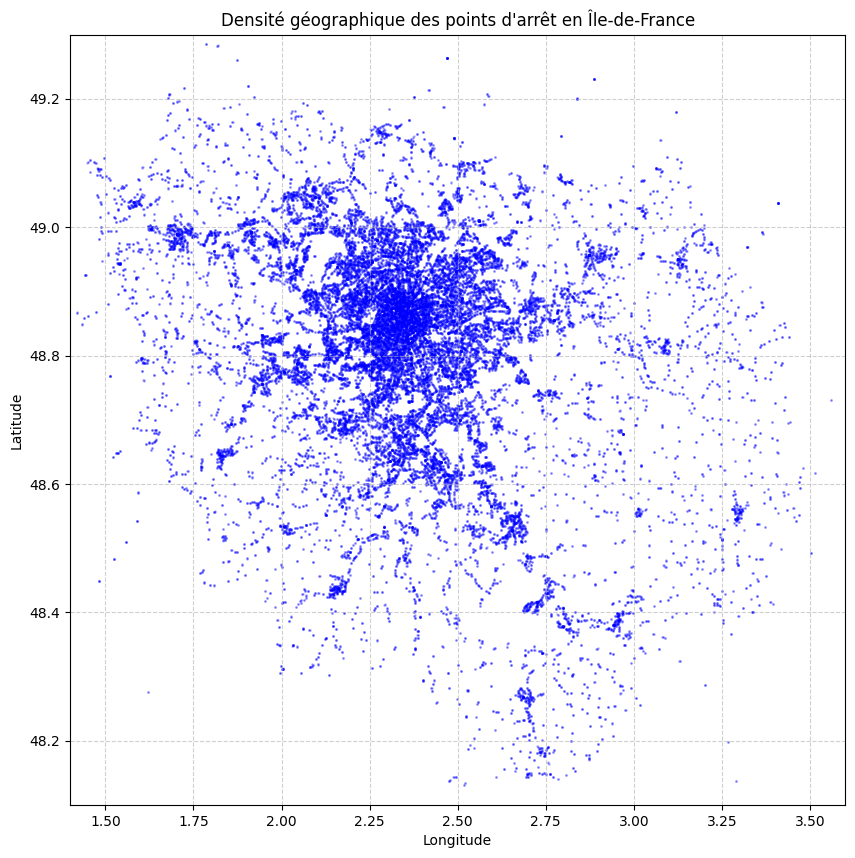

In [13]:
# Récupération des coordonnées GPS des arrêts
coords_stops = dfs["stops"].select("stop_lon", "stop_lat").toPandas()

# Visualisation par nuage de points (Scatter Plot)
plt.figure(figsize=(10, 10))
plt.scatter(coords_stops["stop_lon"], coords_stops["stop_lat"], s=1, alpha=0.2, color='blue')
plt.title("Densité géographique des points d'arrêt en Île-de-France")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.6)
# Ajustement des limites pour se concentrer sur l'IdF (évite les points aberrants)
plt.xlim(1.4, 3.6)
plt.ylim(48.1, 49.3)
plt.show()

# Interprétation 

Cette carte nous montre les points d'arrêt en ile de france. Plus l'on s'approche du centre de Paris, plus la densite de ces points est élevée. À l'inverse, plus l'on s'éloigne du centre, plus les arrêts sont éparpillés et servent à desservir les communes alentours de Paris. 

Nous pouvons donc dire que le réseau d'arrêt de Paris est concentré progrssivement vers le centre.

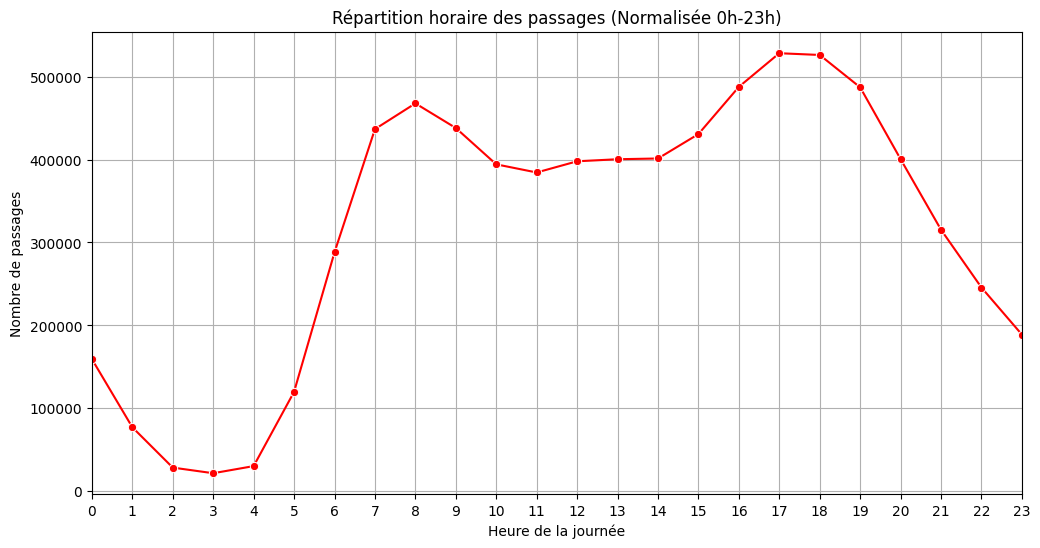

In [21]:
# 1. Extraction de l'heure avec application du modulo 24
# L'expression (hour % 24) permet de replacer les services de nuit dans la journée standard
temp_dist = dfs["stop_times"].withColumn("hour_raw", split(col("arrival_time"), ":")[0].cast("int")) \
    .withColumn("hour", expr("hour_raw % 24")) \
    .groupBy("hour") \
    .count() \
    .orderBy("hour")

# 2. Conversion en Pandas
pdf_temp = temp_dist.toPandas()

# 3. Visualisation
plt.figure(figsize=(12, 6))
sns.lineplot(data=pdf_temp, x="hour", y="count", marker="o", color="red")

# On fixe les limites de l'axe X strictement entre 0 et 23
plt.xticks(range(0, 24))
plt.xlim(0, 23)

plt.title("Répartition horaire des passages (Normalisée 0h-23h)")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre de passages")
plt.grid(True)
plt.show()

# Interprétation

On identifie clairement deux pics d'activité correspondant aux heures de pointe (7h-9h et 16h-19h). Cette courbe est typique des réseaux de transport pendulaires où l'offre est massivement renforcée pour absorber les flux de travailleurs et d'étudiants.

# Partie 3 : Synthèse Globale

1. Bilan et Principales Découvertes
Cette étude exploratoire, menée sur le jeu de données GTFS d'Île-de-France couvrant la période de janvier à février 2026, a permis de caractériser la structure et la dynamique d'un des réseaux de transport les plus denses d'Europe. L'analyse de 7,6 millions d'horaires et 2 000 lignes met en lumière trois dimensions fondamentales :

*Une offre massivement dominée par le Bus* : L'analyse de la répartition modale révèle une hégémonie du transport routier. Sur les 2 000 lignes actives, 1 941 sont des lignes de bus (97 %). Bien que les modes lourds (Métro, Train, Tramway) soient structurants, le maillage fin du territoire repose quasi-intégralement sur le réseau de bus. Cela confirme une stratégie de couverture "du dernier kilomètre" très étendue (plus de 53 000 arrêts).

*Une gouvernance hybride : Centralisation et Fragmentation* : Le paysage opérationnel illustre la dualité du réseau francilien. D'un côté, la RATP reste l'acteur ultra-dominant avec 287 lignes gérées en propre. De l'autre, on observe une forte fragmentation territoriale avec des opérateurs délégués par zones (ex: Centre et Sud Yvelines avec 109 lignes, Poissy - Les Mureaux avec 88 lignes). Cette structure reflète l'organisation administrative des délégations de service public en grande couronne.

*Accessibilité* : Un chantier en bonne voie mais inachevé : L'analyse du champ wheelchair_accessible montre que 66,85 % des trajets sont théoriquement accessibles aux personnes à mobilité réduite. Cependant, pour 16,25 % des trajets, l'information est manquante (valeur 0), ce qui constitue une zone d'ombre majeure pour l'usager dépendant de ces informations.

*Polarité du réseau* : L'étude de la connectivité a identifié des hubs majeurs en dehors de Paris intra-muros, notamment la Gare de Meaux (connectée à 35 lignes), soulignant l'importance des pôles d'échanges multimodaux en grande couronne pour rabattre les flux vers le réseau ferré.

2. Limites de l'Étude
Malgré la richesse des données GTFS, cette analyse comporte plusieurs limites intrinsèques qu'il est nécessaire de souligner pour nuancer les résultats :

*Nature Théorique des Données* : Le format GTFS décrit l'offre planifiée (horaires théoriques). Notre étude ne prend pas en compte la réalité opérationnelle : retards, annulations, grèves ou incidents techniques qui dégradent l'offre réelle.

*Période d'Observation Restreinte* : Les données ne couvrent qu'un mois d'hiver (janvier-février 2026). Elles ne permettent pas d'analyser la saisonnalité (offres d'été, vacances scolaires) ni les variations de trafic sur une année complète.

*Qualité des Métadonnées* : Certaines colonnes présentent des taux de valeurs manquantes critiques. Par exemple, l'absence de données dans parent_station pour 28,5 % des arrêts complique le regroupement des arrêts en "pôles d'échanges" logiques. De même, les informations tarifaires (agency_fare_url) ou de contact sont souvent vides.

*Biais "Arrêt" vs "Ligne"* : Compter le nombre de lignes par opérateur favorise les opérateurs de bus. Une analyse pondérée par le "nombre de kilomètres parcourus" ou la "capacité voyageurs" aurait sans doute redonné plus de poids aux opérateurs ferroviaires (SNCF/RATP métro) qui transportent plus de monde avec moins de "lignes".

3. Recommandations
Au vu des résultats, nous formulons les recommandations suivantes à l'attention de l'autorité organisatrice (IDFM) :

*Fiabilisation de la donnée Accessibilité* : Auditer les 16 % de trajets dont l'accessibilité est "inconnue" pour fournir une information fiable à 100 % aux usagers PMR.

*Renforcement de l'offre week-end* : Si l'analyse temporelle confirme une baisse drastique de l'offre le week-end (orientée "trajets domicile-travail"), il serait pertinent de renforcer les lignes desservant les zones de loisirs et les grands hubs comme Meaux le samedi.

4. Pistes d'Approfondissement (Perspectives)
Pour aller plus loin dans la compréhension du réseau, les analyses suivantes pourraient être menées avec des outils Big Data avancés :

*Analyse de Graphe (GraphX / GraphFrames)* : Modéliser le réseau sous forme de graphe (Arrêts = Nœuds, Trajets = Arêtes) permettrait de calculer des indicateurs de centralité (PageRank) pour identifier les arrêts les plus critiques en cas de panne, ou de calculer les temps de parcours minimums entre deux points quelconques de la région.

*Croisement de Données (Open Data)* : Croiser la densité des arrêts avec les données carroyées de l'INSEE (densité de population) permettrait d'identifier objectivement les "zones blanches" ou les quartiers mal desservis par rapport à leur population.

*Analyse Temporelle Fine* : Visualiser la densité du trafic heure par heure (Heatmap temporelle) pour distinguer précisément les heures de pointe des heures creuses par département.